In [ ]:
import pandas as pd
import numpy as np

from pathlib import Path

from matplotlib import pyplot as plt

%matplotlib widget

In [27]:
exam_result_path = Path("/Users/abelluc/FAUbox/DigiKolleg/ADS")

In [28]:
exam_results = pd.read_csv(exam_result_path.joinpath("ADS_24/ADS_Exam_2024_results.csv"), sep=";")
exam_results.head()

,Name,Login,Started Passes,Scored Pass,Test Results in Points,Maximum Available Points,Test Results in Marks,Questions already worked through,Total number of Questions,Percent of total workload already worked through,...,STAT_p-value,STAT_parametric_vs_non-parametric_b,STAT_power,STAT_unifactorial_anova,VIS_boxplots_b,VIS_histograms_2_b,VIS_scatter_plots_2,VIS_scatter_plots_b,VIS_STAT_outliers,VIS_STAT_outliers2_b
0,"Al Husseiny, Mohammad",zy41qyfy,1,1,78.0,100,passed,48,49,0.979592,...,2.0,2.0,2,0.0,2.0,2.0,1.0,2.0,2.0,2.0
1,"Babu, Morris Darren",sa01juwe,1,1,53.0,100,passed,41,49,0.836735,...,0.0,2.0,0,1.0,NaN,2.0,1.0,2.0,2.0,2.0
2,"Bastani, Parisa",ze30qyse,1,1,87.0,100,passed,49,49,1.000000,...,2.0,2.0,2,1.0,2.0,2.0,2.0,1.0,2.0,2.0
3,"Bayazit, Tevrat",he28wiwy,1,1,35.5,100,failed,35,49,0.714286,...,1.0,2.0,1,NaN,1.5,2.0,0.0,0.0,1.0,2.0
4,"Beck, Fiona",za41xuki,1,1,80.0,100,passed,49,49,1.000000,...,2.0,0.0,2,1.0,2.0,2.0,0.0,2.0,2.0,2.0


In [29]:
#handle special cases

exam_results.replace("exam76964", "ej80ogyg", inplace=True)

In [30]:
exam_results.set_index("Login", inplace=True)
exam_results.index.names = ["student_id"]
exam_results.head()

,Name,Started Passes,Scored Pass,Test Results in Points,Maximum Available Points,Test Results in Marks,Questions already worked through,Total number of Questions,Percent of total workload already worked through,Time of Work,...,STAT_p-value,STAT_parametric_vs_non-parametric_b,STAT_power,STAT_unifactorial_anova,VIS_boxplots_b,VIS_histograms_2_b,VIS_scatter_plots_2,VIS_scatter_plots_b,VIS_STAT_outliers,VIS_STAT_outliers2_b
student_id,,,,,,,,,,,,,,,,,,,,,
zy41qyfy,"Al Husseiny, Mohammad",1,1,78.0,100,passed,48,49,0.979592,00:55:04,...,2.0,2.0,2,0.0,2.0,2.0,1.0,2.0,2.0,2.0
sa01juwe,"Babu, Morris Darren",1,1,53.0,100,passed,41,49,0.836735,00:40:08,...,0.0,2.0,0,1.0,NaN,2.0,1.0,2.0,2.0,2.0
ze30qyse,"Bastani, Parisa",1,1,87.0,100,passed,49,49,1.000000,00:32:44,...,2.0,2.0,2,1.0,2.0,2.0,2.0,1.0,2.0,2.0
he28wiwy,"Bayazit, Tevrat",1,1,35.5,100,failed,35,49,0.714286,00:50:18,...,1.0,2.0,1,NaN,1.5,2.0,0.0,0.0,1.0,2.0
za41xuki,"Beck, Fiona",1,1,80.0,100,passed,49,49,1.000000,00:59:28,...,2.0,0.0,2,1.0,2.0,2.0,0.0,2.0,2.0,2.0


<Axes: >

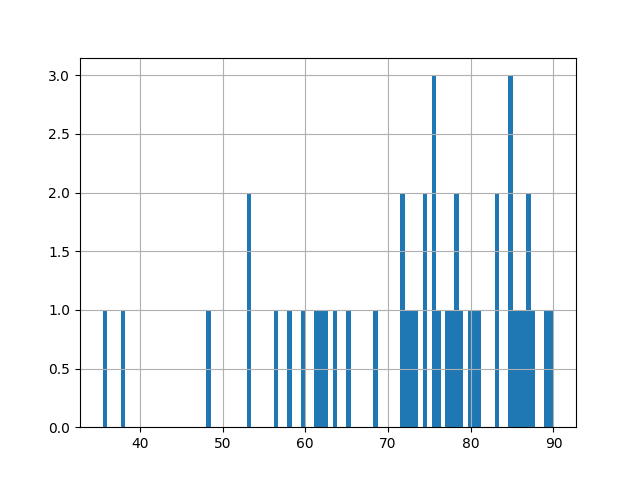

In [31]:
plt.subplots()
points = exam_results["Test Results in Points"]
points.hist(bins=100)

In [32]:
points = pd.DataFrame(points)
points.columns = ["points"]
points.head()

,points
student_id,
zy41qyfy,78.0
sa01juwe,53.0
ze30qyse,87.0
he28wiwy,35.5
za41xuki,80.0


In [33]:
pass_score = 48.0
max_score = 100.0
bin_size = round((max_score-pass_score) / 11, 1)
bin_size

4.7

In [34]:
grades = [1.0, 1.33, 1.66, 2.0, 2.33, 2.66, 3.0, 3.33, 3.66, 4.0, 4.33, 5.0]
grades = grades[::-1]

In [35]:
min_points = [pass_score + bin_size * i for i in range(-2,len(grades)-1)]
min_points

[38.6,
 43.3,
 48.0,
 52.7,
 57.4,
 62.1,
 66.8,
 71.5,
 76.2,
 80.9,
 85.6,
 90.30000000000001,
 95.0]

In [36]:
grade_map = pd.DataFrame(zip(min_points, grades), columns=["min_points", "grade"])
grade_map["max_points"] = grade_map["min_points"] + bin_size - 0.1
grade_map.set_index("grade", inplace=True)
grade_map.loc[1.0, "max_points"] = max_score
grade_map.loc[5.0, "min_points"] = 0.0

grade_map.sort_index(inplace=True)

grade_map

,min_points,max_points
grade,,
1.00,90.3,100.0
1.33,85.6,90.2
1.66,80.9,85.5
2.00,76.2,80.8
2.33,71.5,76.1
2.66,66.8,71.4
3.00,62.1,66.7
3.33,57.4,62.0
3.66,52.7,57.3


In [37]:
# return the value of the index of grade_map where points is between min_points and max_points
points["grade"] = [grade_map[(grade_map["min_points"] <= point) & (grade_map["max_points"] >= point)].index[0] for point in points["points"]]
points


,points,grade
student_id,,
zy41qyfy,78.0,2.00
sa01juwe,53.0,3.66
ze30qyse,87.0,1.33
he28wiwy,35.5,5.00
za41xuki,80.0,2.00
to10fape,81.0,1.66
un24acof,71.5,2.33
vy30goxy,73.0,2.33
ty02muwa,90.0,1.33


<Axes: >

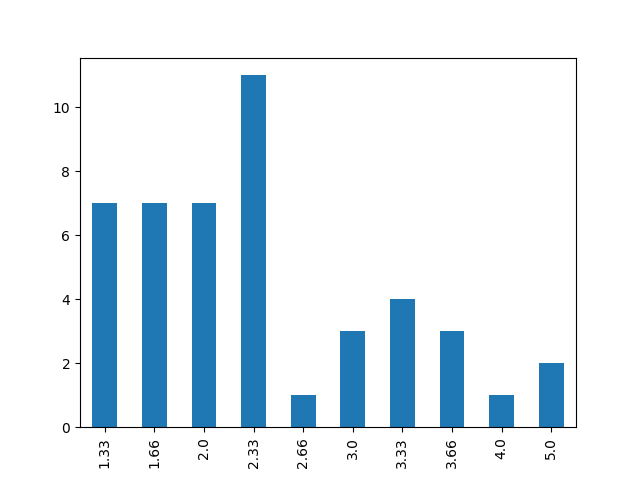

In [38]:
# Without Bonus

plt.subplots()

points["grade"].value_counts().sort_index().plot(kind="bar")

In [39]:
bonus_points = pd.read_csv("/Users/abelluc/Code/ads_exercise/total_score/2024_final.csv")
bonus_points.set_index("identifier", inplace=True)
bonus_points.index.names = ["student_id"]
bonus_points

,score_percent
student_id,
ac13atok,9.0
ac28azeg,1.0
ag46abiw,0.0
as73isud,100.0
at74ynyg,2.5
cu40xetu,95.5
cy73sela,41.0
ec40odyf,35.0
ej80ogyg,0.0


In [40]:
# join points and bonus_points

points = points.join(bonus_points)
# points.drop("student_id", axis=1, inplace=True)
points

,points,grade,score_percent
student_id,,,
zy41qyfy,78.0,2.00,88.0
sa01juwe,53.0,3.66,18.0
ze30qyse,87.0,1.33,95.5
he28wiwy,35.5,5.00,NaN
za41xuki,80.0,2.00,80.0
to10fape,81.0,1.66,100.0
un24acof,71.5,2.33,NaN
vy30goxy,73.0,2.33,100.0
ty02muwa,90.0,1.33,99.5


In [41]:
# replace values in score_percent with 0.33, 0.66, 1.0
points["bonus"] = np.zeros(len(points))

points["bonus"][points["score_percent"] >= 95] = 0.66
points["score_percent"][points["score_percent"] >= 95] = 0

points["bonus"][points["score_percent"] >= 90] = 0.33

# replace nan with 0
points.fillna(0, inplace=True)

points.drop("score_percent", axis=1, inplace=True)
points

,points,grade,bonus
student_id,,,
zy41qyfy,78.0,2.00,0.00
sa01juwe,53.0,3.66,0.00
ze30qyse,87.0,1.33,0.66
he28wiwy,35.5,5.00,0.00
za41xuki,80.0,2.00,0.00
to10fape,81.0,1.66,0.66
un24acof,71.5,2.33,0.00
vy30goxy,73.0,2.33,0.66
ty02muwa,90.0,1.33,0.66


In [42]:
points["grade_with_bonus"] = points["grade"] - points["bonus"]

# set grade_with_bonus to 1.0 if grade_with_bonus is smaller than 1.0
points["grade_with_bonus"][points["grade_with_bonus"] < 1.0] = 1.0

# set grade_with_bonus to grade value if grade is greater than 4.0
points["grade_with_bonus"][points["grade"] > 4.0] = points["grade"]

points

,points,grade,bonus,grade_with_bonus
student_id,,,,
zy41qyfy,78.0,2.00,0.00,2.00
sa01juwe,53.0,3.66,0.00,3.66
ze30qyse,87.0,1.33,0.66,1.00
he28wiwy,35.5,5.00,0.00,5.00
za41xuki,80.0,2.00,0.00,2.00
to10fape,81.0,1.66,0.66,1.00
un24acof,71.5,2.33,0.00,2.33
vy30goxy,73.0,2.33,0.66,1.67
ty02muwa,90.0,1.33,0.66,1.00


In [43]:
points = round(points, 1)
points.sort_values("grade", inplace=True)
points

,points,grade,bonus,grade_with_bonus
student_id,,,,
hi03vuqi,86.0,1.3,0.7,1.0
ny39myjo.1,87.5,1.3,0.0,1.3
ze30qyse,87.0,1.3,0.7,1.0
cu40xetu,89.0,1.3,0.7,1.0
yr92osyb,87.0,1.3,0.7,1.0
ty02muwa,90.0,1.3,0.7,1.0
fi46dely,86.5,1.3,0.7,1.0
to10fape,81.0,1.7,0.7,1.0
nu84byna,85.0,1.7,0.3,1.3


In [44]:
points.describe()

,points,grade,bonus,grade_with_bonus
count,46.000000,46.000000,46.000000,46.000000
mean,72.847826,2.397826,0.234783,2.221739
std,13.220720,0.927239,0.330130,1.018258
min,35.500000,1.300000,0.000000,1.000000
25%,63.875000,1.700000,0.000000,1.400000
50%,75.500000,2.300000,0.000000,2.150000
75%,83.000000,3.000000,0.700000,2.700000
max,90.000000,5.000000,0.700000,5.000000


<Axes: >

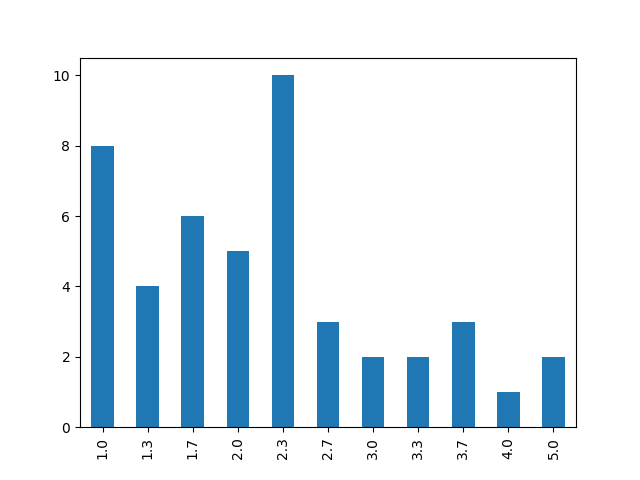

In [45]:
plt.subplots()
points["grade_with_bonus"].value_counts().sort_index().plot(kind="bar")

In [46]:
# save to csv
points.sort_index().to_csv(exam_result_path.joinpath("ADS_Exam_2024_results_final.csv"))